# Tutorial 3: Running Quantization-Aware Training (QAT) on Bert

In this tutorial, we'll build on top of Tutorial 2 by taking the Bert model fine tuned for sequence classification and running Mase's quantization pass. First, we'll run simple Post-Training Quantization (PTQ) and see how much accuracy drops. Then, we'll run some further training iterations of the quantized model (i.e. QAT) and see whether the accuracy of the trained quantized model approaches the accuracy of the original (full-precision) model.

In [5]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [2]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.


tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on LoRA Finetuning, run the following cell to import the fine tuned checkpoint.

In [6]:
from pathlib import Path
from chop import MaseGraph

mg = MaseGraph.from_checkpoint("/workspace/mase-tools/mase/labs_2024_ak821/tutorial_2/tutorial_2_lora")

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.


## Post-Training Quantization (PTQ)

Here, we simply quantize the model and evaluate the effect in its accuracy. First, let's evaluate the model accuracy before quantization (if you're coming from Tutorial 2, this should be the same as the post-LoRA evaluation accuracy). As seen in Tutorial 2, we can use the `get_tokenized_dataset` and `get_trainer` utilities to generate a HuggingFace `Trainer` instance for training and evaluation.

In [7]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

/workspace/mase-tools/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.83556


To run the quantization pass, we pass a quantization configuration dictionary as argument. This defines the quantization mode, numerical format and precision for each operator in the graph. We'll run the quantization in "by type" mode, meaning nodes are quantized according to their `mase_op`. Other modes include by name and by regex name. We'll quantize all activations, weights and biases in the model to fixed-point with the same precision. This may be sub-optimal, but works as an example. In future tutorials, we'll see how to run the `search` flow in `Mase` to find optimal quantization configurations to minimize accuracy loss.

In [5]:
import chop.passes as passes

quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

mg, _ = passes.quantize_transform_pass(
    mg,
    pass_args=quantization_config,
)

Let's evaluate the immediate effect of quantization on the model accuracy.

In [6]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/workspace/mase-tools/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.48804


We can save the current checkpoint for future reference (optional).

In [7]:
from pathlib import Path

mg.export("/workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_ptq")

INFO     Exporting MaseGraph to /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_ptq.pt, /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_ptq.mz
INFO     Exporting GraphModule to /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_ptq.pt
INFO     Exporting MaseMetadata to /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_ptq.mz
WARNING  Failed to pickle call_function node: finfo
WARNING  cannot pickle 'torch.finfo' object
WARNING  Failed to pickle call_function node: getattr_2
WARNING  cannot pickle 'torch.finfo' object


## Quantization-Aware Training (QAT)

You should have seen in the last section that quantization can lead to a significant drop in accuracy. Next, we'll run QAT to evaluate whether this performance gap can be reduced. To run QAT in Mase, all you need to do is include the model back in your training loop after running the quantization pass.

In [8]:
# Evaluate accuracy
trainer.train()
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Step,Training Loss
500,0.633000
1000,0.475700
1500,0.426800
2000,0.390200
2500,0.375500
3000,0.381700


Evaluation accuracy: 0.8586


We can see the accuracy of the quantized model can match (or sometimes exceed) the full precision model, with a much lower memory requirement to store the weights. Finally, save the final checkpoint for future tutorials.

In [9]:
from pathlib import Path

mg.export("/workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_qat")

INFO     Exporting MaseGraph to /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_qat.pt, /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_qat.mz
INFO     Exporting GraphModule to /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_qat.pt
INFO     Exporting MaseMetadata to /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_qat.mz
WARNING  Failed to pickle call_function node: finfo
WARNING  cannot pickle 'torch.finfo' object
WARNING  Failed to pickle call_function node: getattr_2
WARNING  cannot pickle 'torch.finfo' object


# Task 1

In [2]:
def get_config(width):
    return {
        "by": "type",
        "default": {
            "config": {
                "name": None,
            }
        },
        "linear": {
            "config": {
                "name": "integer",
                # data
                "data_in_width": width[0],
                "data_in_frac_width": width[1],
                # weight
                "weight_width": width[0],
                "weight_frac_width": width[1],
                # bias
                "bias_width": width[0],
                "bias_frac_width": width[1],
            }
        },
    }

widths = [(4,2), (6,3), (8,4), (10,5), (12,6), (16,8), (32,16)]
results = []

In [9]:
import pandas as pd
from chop.tools import get_trainer
import chop.passes as passes

for w in widths:
    total_width, frac_width = w
    config = get_config(w)
    print(f"\n=== Processing fixed point width: {total_width} (frac: {frac_width}) ===")
    
    # Load the model from a checkpoint.
    mg = MaseGraph.from_checkpoint(
        "/workspace/mase-tools/mase/labs_2024_ak821/tutorial_2/tutorial_2_lora"
    )
    
    # === POST-TRAINING QUANTIZATION (PTQ) ===
    mg_ptq, _ = passes.quantize_transform_pass(mg, pass_args=config)
    
    # Create a trainer for the PTQ model.
    trainer_ptq = get_trainer(
        model=mg_ptq.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
    )
    
    # Evaluate PTQ accuracy.
    eval_results_ptq = trainer_ptq.evaluate()
    ptq_accuracy = eval_results_ptq.get("eval_accuracy")
    print(f"PTQ Evaluation accuracy: {ptq_accuracy:.3f}")
    
    # === QUANTIZATION-AWARE TRAINING (QAT) ===
    # Continue training the already-quantized model.
    trainer_ptq.train()
    eval_results_qat = trainer_ptq.evaluate()
    qat_accuracy = eval_results_qat.get("eval_accuracy")
    print(f"QAT Evaluation accuracy: {qat_accuracy:.3f}")
    
    results.append({
        "total_width": total_width,
        "frac_width": frac_width,
        "PTQ_accuracy_percent": ptq_accuracy * 100,
        "QAT_accuracy_percent": qat_accuracy * 100,
    })

df = pd.DataFrame(results)
print("\nSummary of quantization results:")
display(df)


WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.



=== Processing fixed point width: 4 (frac: 2) ===


/workspace/mase-tools/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


PTQ Evaluation accuracy: 0.500


Step,Training Loss
500,0.693100
1000,0.693100
1500,0.693100
2000,0.693100
2500,0.693100
3000,0.693100


...

/workspace/mase-tools/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


PTQ Evaluation accuracy: 0.836


Step,Training Loss
500,0.379500
1000,0.380300
1500,0.396500
2000,0.382200
2500,0.383700
3000,0.397400


QAT Evaluation accuracy: 0.841

Summary of quantization results:


,total_width,frac_width,PTQ_accuracy_percent,QAT_accuracy_percent
0,4,2,50.000,50.000
1,6,3,63.528,82.968
2,8,4,78.404,84.108
3,10,5,80.320,84.052
4,12,6,83.324,84.124
5,16,8,83.476,84.128
6,32,16,83.556,84.064


In [10]:
csv_filename = "quantization_results.csv"
df.to_csv(csv_filename, index=False)
print(f"\nResults exported to {csv_filename}")


Results exported to quantization_results.csv


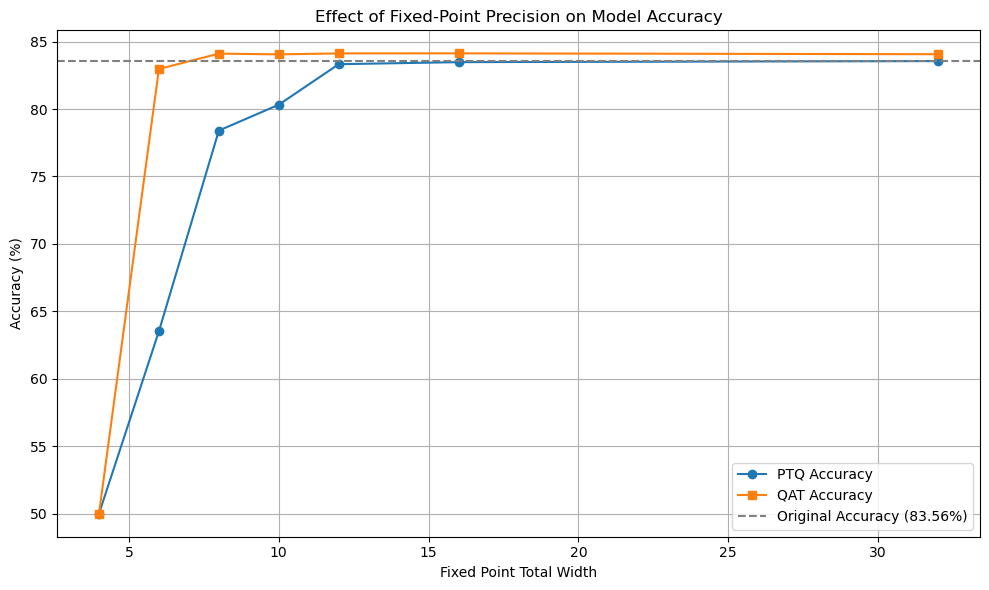

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['total_width'], df['PTQ_accuracy_percent'], marker='o', label='PTQ Accuracy')
plt.plot(df['total_width'], df['QAT_accuracy_percent'], marker='s', label='QAT Accuracy')

original_accuracy = 83.56
plt.axhline(y=original_accuracy, color='gray', linestyle='--', label=f'Original Accuracy ({original_accuracy}%)')

plt.xlabel('Fixed Point Total Width')
plt.ylabel('Accuracy (%)')
plt.title('Effect of Fixed-Point Precision on Model Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("quantization_accuracy_plot_with_reference.png")
plt.show()


In [14]:
# best config
mg = MaseGraph.from_checkpoint(
    "/workspace/mase-tools/mase/labs_2024_ak821/tutorial_2/tutorial_2_lora"
)

mg, _ = passes.quantize_transform_pass(mg, pass_args=get_config((8,4)))

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

trainer.train()

mg.export("/workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_best_fixpoint8_qat")
eval_results = trainer.evaluate()

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
/workspace/mase-tools/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.399300
1000,0.393200
1500,0.404200
2000,0.392900
2500,0.393200
3000,0.401700


INFO     Exporting MaseGraph to /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_best_fixpoint8_qat.pt, /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_best_fixpoint8_qat.mz
INFO     Exporting GraphModule to /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_best_fixpoint8_qat.pt
INFO     Exporting MaseMetadata to /workspace/mase-tools/mase/labs_2024_ak821/tutorial_3/tutorial_3_best_fixpoint8_qat.mz
